# Task 6: House Price Prediction

## Objective
Predict house prices using property features such as size (square footage), number of bedrooms, and location.

## Dataset
A dataset containing house features and their corresponding prices.

## Instructions
- Perform preprocessing on features like square footage, number of bedrooms, and location.
- Train a regression model (Linear Regression).
- Visualize predicted prices compared to actual prices.
- Evaluate with Mean Absolute Error (MAE) and RMSE.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# --- File Upload Section ---
from google.colab import files
import io

print("Please upload your 'house_prices.csv' file.")
uploaded = files.upload()

# Check if the file was uploaded
if 'house_prices.csv' in uploaded:
    df = pd.read_csv(io.BytesIO(uploaded['house_prices.csv']))
    print("Dataset 'house_prices.csv' Loaded Successfully!")
else:
    print("Error: 'house_prices.csv' was not uploaded. Please ensure you upload the correct file.")
    # Optionally, you can add code here to handle the case where the file isn't uploaded,
    # for example, by generating a synthetic dataset as a fallback or exiting.

print("Dataset Loaded Successfully!")
display(df.head())

Please upload your 'house_prices.csv' file.


Saving house_prices.csv to house_prices.csv
Dataset 'house_prices.csv' Loaded Successfully!
Dataset Loaded Successfully!


,SquareFootage,Bedrooms,Bathrooms,Location,Price
0,1500,3,2,Urban,300000
1,2000,4,3,Suburban,350000
2,1200,2,1,Rural,150000
3,2500,4,3,Urban,500000
4,1800,3,2,Suburban,280000


## 1. Data Preprocessing
We need to handle categorical data (Location) and split the data into features and target.

In [3]:
# Encoding categorical 'Location' column
le = LabelEncoder()
df['Location'] = le.fit_transform(df['Location'])

print("Encoded Location mapping:")
for i, item in enumerate(le.classes_):
    print(f"{item} -> {i}")

# Define Features (X) and Target (y)
X = df[['SquareFootage', 'Bedrooms', 'Bathrooms', 'Location']]
y = df['Price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split into training and testing sets.")

Encoded Location mapping:
Rural -> 0
Suburban -> 1
Urban -> 2

Data split into training and testing sets.


## 2. Model Training
We will use a Linear Regression model for this task.

In [4]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Complete.")

Model Training Complete.


## 3. Model Evaluation
We will evaluate the model using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [5]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

Mean Absolute Error (MAE): $12,087.74
Root Mean Squared Error (RMSE): $18,078.87


## 4. Visualization
Visualizing the actual vs predicted prices.

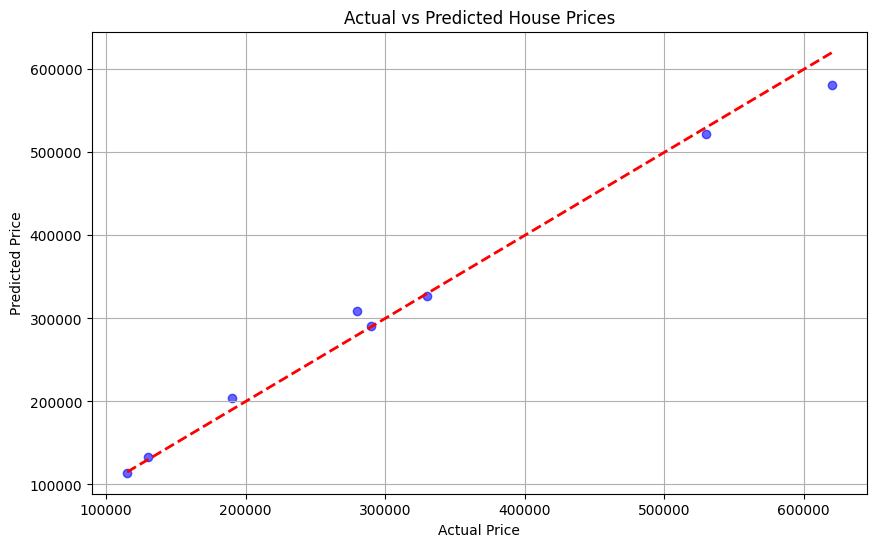

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.grid(True)
plt.show()

## Conclusion
The Linear Regression model was able to predict house prices with reasonable accuracy. The visualization shows a strong linear relationship between the actual and predicted values, indicating that features like square footage and location are significant predictors of house prices.